In [4]:
%load_ext autoreload
%autoreload 2

import itables
import sys
from strategy_v5.lib.strategy import *
from strategy_v5.lib.portfolio import Portfolio, RebalanceFrequency
from strategy_v5.lib.executor import Executor
from strategy_v5.lib.evaluator import PortfolioEvaluator
from datetime import datetime
from pandas.tseries.offsets import BDay
import pandas as pd

pd.options.display.float_format = '{:,.4f}'.format
itables.init_notebook_mode()
itables.options.allow_html = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
instruments = [
    'META',
    'TSLA',
    'NVDA',
    'AAPL',        
    'BRK-B',
    # 'SPY',
    'QQQ',
    'NANC',        
    #'CASH',
]

initial_capital = 100_000
end_date = (datetime.today() - BDay(1))
start_date = end_date - BDay(250)

In [33]:
# Create Portfolios
portfolios = [
    Portfolio(
        name = 'EQUAL WEIGHT',
        instruments=instruments,
        initial_capital=initial_capital,
        strategy=WeightRebalance(),
        rebalance_freq=RebalanceFrequency.MONTHLY,
        rebalance_day=1
    ),

    Portfolio(
        name = 'BUY & HOLD',
        instruments=instruments,
        initial_capital=initial_capital,
        strategy=BuyAndHoldRebalance(),
        rebalance_freq=RebalanceFrequency.MONTHLY,
        rebalance_day=1
    ),

    Portfolio(
        name = 'MVO MOMENTUM',
        instruments=instruments,
        initial_capital=initial_capital,
        strategy=MVOMomentumRebalance(
            lookback_days=20, 
            max_weight=1/len(instruments) + 0.05, 
            min_weight=1/len(instruments) - 0.05, 
            risk_aversion=1, 
            use_shrinkage=True
        ),
        rebalance_freq=RebalanceFrequency.MONTHLY,
        rebalance_day=1
    ),

    Portfolio(
        name = 'MVO MEAN REVERSION',
        instruments=instruments,
        initial_capital=initial_capital,
        strategy=MVOMeanRevertRebalance(
            lookback_days=20, 
            max_weight=1/len(instruments) + 0.05, 
            min_weight=1/len(instruments) - 0.05, 
            risk_aversion=1, 
            use_shrinkage=True
        ),
        rebalance_freq=RebalanceFrequency.MONTHLY,
        rebalance_day=1
    ),

    Portfolio(
        name = 'SPY Benchmark',
        instruments=['SPY'],
        initial_capital=initial_capital,
        strategy=BuyAndHoldRebalance(),        
    ),

    Portfolio(
        name = 'QQQ Benchmark',
        instruments=['QQQ'],
        initial_capital=initial_capital,
        strategy=BuyAndHoldRebalance(),        
    )
]

# Execute backtests
for portfolio in portfolios:
    Executor(portfolio).run(start_date, end_date, verbose=False)

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


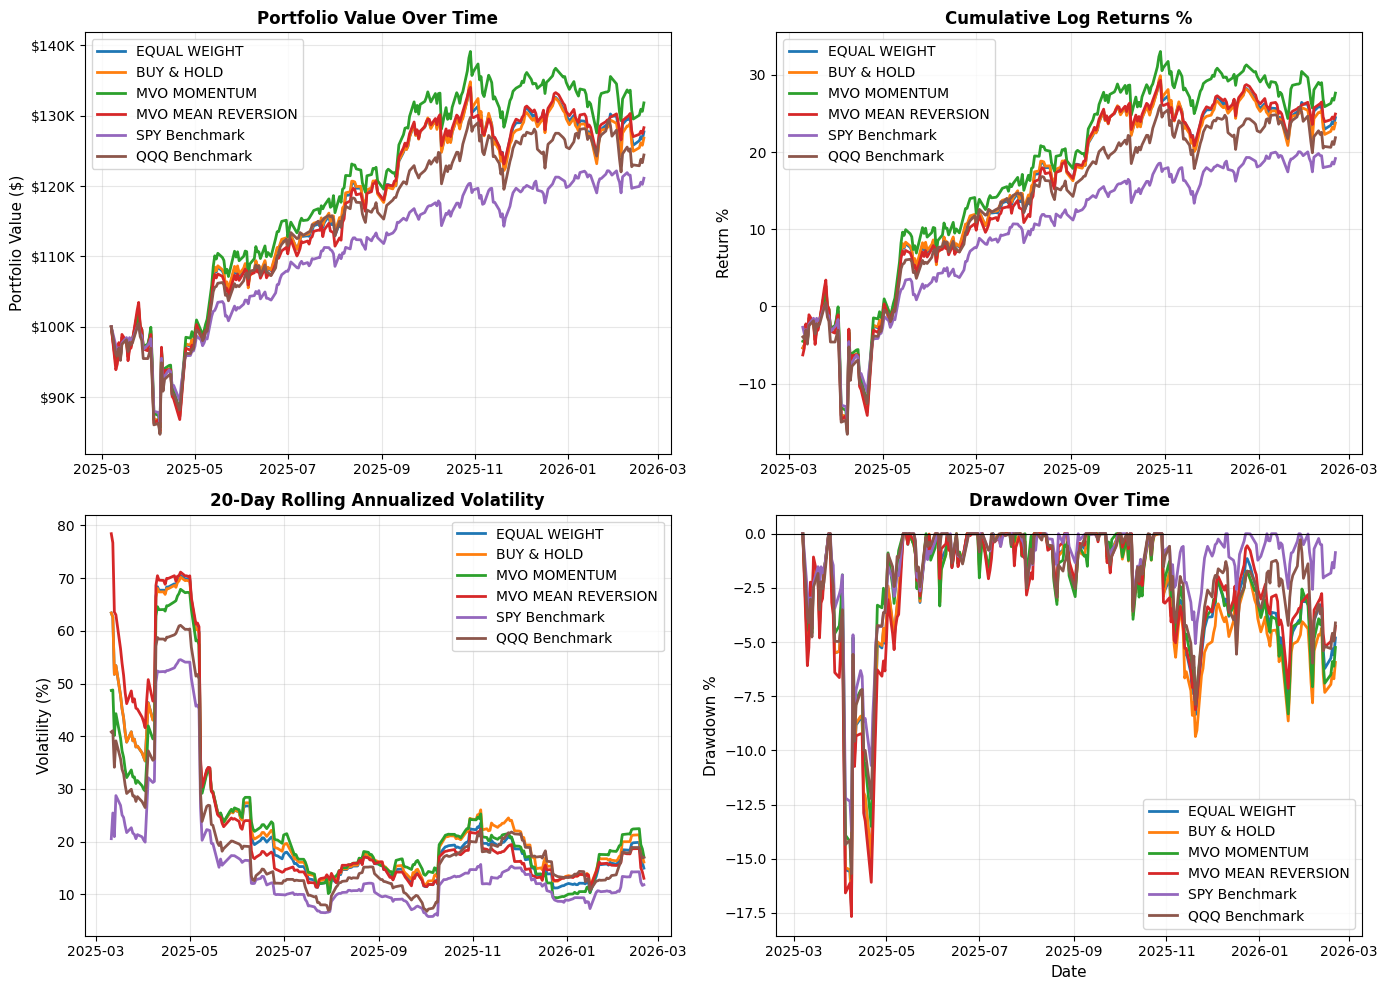

In [34]:
# Evaluate and compare portfolios
evaluator = PortfolioEvaluator(portfolios)
metrics = evaluator.calculate_all_metrics()

evaluator.print_comparison(format=True)
evaluator.plot_comparison(figsize=(14, 10), show_rebalance_markers=False)

In [35]:
portfolio = portfolios[2]  # MVO MOMENTUM
evaluator = PortfolioEvaluator(portfolio)
evaluator.plot_weights_history()